In [6]:
!pip install pandas numpy scikit-learn xgboost shap plotly


In [7]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_kddcup99
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [8]:
print("Loading dataset...")
kdd = fetch_kddcup99(as_frame=True)
df = kdd.frame
print(f"✅ Dataset loaded!")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
df.head()

Loading dataset...
✅ Dataset loaded!
Rows    : 494021
Columns : 42


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,b'tcp',b'http',b'SF',181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,b'normal.'
1,0,b'tcp',b'http',b'SF',239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,b'normal.'
2,0,b'tcp',b'http',b'SF',235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,b'normal.'
3,0,b'tcp',b'http',b'SF',219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,b'normal.'
4,0,b'tcp',b'http',b'SF',217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,b'normal.'


In [9]:
# Take a sample of 50,000 rows
df_sample = df.sample(n=50000, random_state=42)

# Encode text columns to numbers
le = LabelEncoder()
for col in df_sample.select_dtypes(include='object').columns:
    df_sample[col] = le.fit_transform(df_sample[col].astype(str))

# Separate features and labels
X = df_sample.drop('labels', axis=1)
y = df_sample['labels']

# FIX — Re-encode labels to start from 0
le_labels = LabelEncoder()
y = le_labels.fit_transform(y)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("✅ Data cleaned and prepared!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Unique classes   : {len(set(y))}")

✅ Data cleaned and prepared!
Training samples : 40000
Testing samples  : 10000
Unique classes   : 17


In [10]:
print("🔍 Training Isolation Forest...")

iso_forest = IsolationForest(
    contamination=0.1,
    random_state=42,
    n_estimators=100
)

iso_forest.fit(X_train)
iso_predictions = iso_forest.predict(X_test)

anomalies = (iso_predictions == -1).sum()
normal = (iso_predictions == 1).sum()

print(f"✅ Isolation Forest trained!")
print(f"🔴 Anomalies detected : {anomalies}")
print(f"🟢 Normal traffic     : {normal}")
print(f"📊 Anomaly rate       : {anomalies/len(iso_predictions)*100:.2f}%")

🔍 Training Isolation Forest...
✅ Isolation Forest trained!
🔴 Anomalies detected : 1029
🟢 Normal traffic     : 8971
📊 Anomaly rate       : 10.29%


In [11]:
import xgboost as xgb
from sklearn.metrics import classification_report
import numpy as np

print("🎯 Training XGBoost Classifier...")

# Convert to numpy arrays
y_train_arr = np.array(y_train)
y_test_arr = np.array(y_test)

# Keep only test samples whose class exists in training
mask = np.isin(y_test_arr, np.unique(y_train_arr))
X_test_filtered = X_test[mask]
y_test_filtered = y_test_arr[mask]

# Remap labels to 0,1,2,3... continuously
unique_classes = np.unique(y_train_arr)
label_map = {old: new for new, old in enumerate(unique_classes)}

y_train_fixed = np.array([label_map[i] for i in y_train_arr])
y_test_fixed = np.array([label_map[i] for i in y_test_filtered])

print(f"Classes in training : {len(unique_classes)}")
print(f"Test samples after filter : {len(y_test_fixed)}")

# Build and train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train_fixed)
xgb_predictions = xgb_model.predict(X_test_filtered)

print("✅ XGBoost trained successfully!")
print("\n📊 Classification Report:")
print(classification_report(y_test_fixed, xgb_predictions))

🎯 Training XGBoost Classifier...
Classes in training : 16
Test samples after filter : 9999
✅ XGBoost trained successfully!

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           4       1.00      1.00      1.00        26
           7       1.00      1.00      1.00      2156
           8       1.00      0.86      0.92         7
           9       1.00      1.00      1.00      2007
          10       1.00      0.83      0.91         6
          11       1.00      0.95      0.98        21
          12       1.00      0.93      0.96        27
          13       1.00      1.00      1.00      5654
          14       1.00      1.00      1.00        24
          15       1.00      0.93      0.96        29

    accuracy                           1.00      9999
   macro avg       1.00      0.95      0.98      9999
weighted avg       1.00      1.00      1.00      9999



In [12]:
import numpy as np
print(f"y_train unique classes : {np.unique(y_train)}")
print(f"y_test unique classes  : {np.unique(y_test)}")
print(f"y_train min : {y_train.min()}")
print(f"y_train max : {y_train.max()}")

y_train unique classes : [ 0  1  2  3  4  5  6  7  8  9 11 12 13 14 15 16]
y_test unique classes  : [ 0  4  7  8  9 10 11 12 13 14 15 16]
y_train min : 0
y_train max : 16


🔍 Running SHAP Explainability...
✅ SHAP values calculated!
Shape of SHAP values : 100
SHAP array shape : (100, 41, 16)


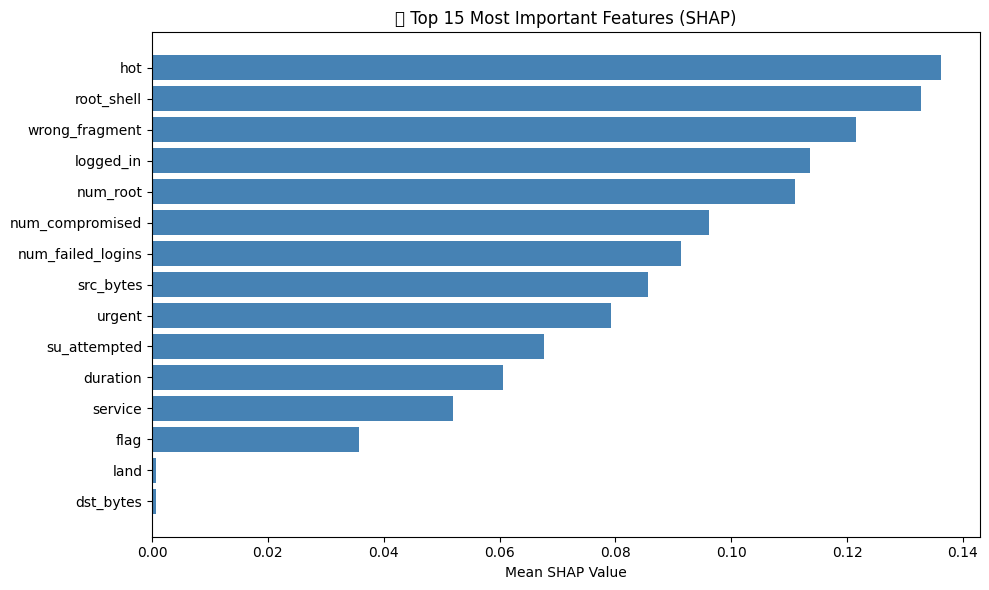

✅ Feature importance plot done!


In [13]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("🔍 Running SHAP Explainability...")

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Take small sample for explanation
X_sample = X_test_filtered[:100]

# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

print("✅ SHAP values calculated!")
print(f"Shape of SHAP values : {len(shap_values)}")

# Convert to numpy array
shap_array = np.array(shap_values)
print(f"SHAP array shape : {shap_array.shape}")

# Plot — Mean absolute SHAP values (feature importance)
mean_shap = np.abs(shap_array).mean(axis=(0, 1))

# Get feature names
feature_names = list(X.columns)

# Sort by importance
sorted_idx = np.argsort(mean_shap)[-15:]  # top 15 features

plt.figure(figsize=(10, 6))
plt.barh(
    [feature_names[i] for i in sorted_idx],
    mean_shap[sorted_idx],
    color='steelblue'
)
plt.title("🔍 Top 15 Most Important Features (SHAP)")
plt.xlabel("Mean SHAP Value")
plt.tight_layout()
plt.show()

print("✅ Feature importance plot done!")

In [14]:
import datetime
import pandas as pd

print("🛡️ Initializing Auto Response Engine...")

# Response log storage
response_log = []

# Define response actions based on attack type
def get_response_action(attack_class):
    actions = {
        0:  "✅ NORMAL - Allow traffic",
        1:  "🔴 DoS - Block IP + Rate limit",
        2:  "🟠 Probe - Flag + Monitor closely",
        3:  "🟡 R2L - Block IP + Alert admin",
        4:  "🔵 U2R - Isolate system + Emergency alert",
        5:  "🔴 DoS - Block IP + Rate limit",
        6:  "🟠 Probe - Flag + Monitor closely",
        7:  "🔴 DoS - Block IP + Rate limit",
        8:  "🟡 R2L - Block IP + Alert admin",
        9:  "🔴 DoS - Block IP + Rate limit",
        10: "🔵 U2R - Isolate system + Emergency alert",
        11: "🟠 Probe - Flag + Monitor closely",
        12: "🟡 R2L - Block IP + Alert admin",
        13: "✅ NORMAL - Allow traffic",
        14: "🔴 DoS - Block IP + Rate limit",
        15: "🟠 Probe - Flag + Monitor closely",
    }
    return actions.get(attack_class, "⚠️ Unknown - Quarantine")

# Severity levels
def get_severity(attack_class):
    severity = {
        0:  "NONE",
        4:  "CRITICAL",
        10: "CRITICAL",
        1:  "HIGH",
        5:  "HIGH",
        7:  "HIGH",
        9:  "HIGH",
        14: "HIGH",
        3:  "MEDIUM",
        8:  "MEDIUM",
        12: "MEDIUM",
        2:  "LOW",
        6:  "LOW",
        11: "LOW",
        15: "LOW",
        13: "NONE",
    }
    return severity.get(attack_class, "UNKNOWN")

print("✅ Auto Response Engine ready!")
print("🔄 Processing detected threats...\n")

# Simulate response for first 10 detections
for i in range(10):
    attack = int(xgb_predictions[i])
    action = get_response_action(attack)
    severity = get_severity(attack)
    timestamp = datetime.datetime.now().strftime("%H:%M:%S")
    fake_ip = f"192.168.{i}.{i*10+1}"

    log_entry = {
        "Time"      : timestamp,
        "IP"        : fake_ip,
        "Class"     : attack,
        "Severity"  : severity,
        "Action"    : action
    }
    response_log.append(log_entry)

# Display response log
log_df = pd.DataFrame(response_log)
print("📋 Auto Response Log:")
print(log_df.to_string(index=False))
print(f"\n✅ {len(response_log)} threats processed automatically!")

🛡️ Initializing Auto Response Engine...
✅ Auto Response Engine ready!
🔄 Processing detected threats...

📋 Auto Response Log:
    Time           IP  Class Severity                        Action
13:16:41  192.168.0.1     13     NONE      ✅ NORMAL - Allow traffic
13:16:41 192.168.1.11     13     NONE      ✅ NORMAL - Allow traffic
13:16:41 192.168.2.21     13     NONE      ✅ NORMAL - Allow traffic
13:16:41 192.168.3.31      7     HIGH 🔴 DoS - Block IP + Rate limit
13:16:41 192.168.4.41     13     NONE      ✅ NORMAL - Allow traffic
13:16:41 192.168.5.51     13     NONE      ✅ NORMAL - Allow traffic
13:16:41 192.168.6.61      9     HIGH 🔴 DoS - Block IP + Rate limit
13:16:41 192.168.7.71     13     NONE      ✅ NORMAL - Allow traffic
13:16:41 192.168.8.81     13     NONE      ✅ NORMAL - Allow traffic
13:16:41 192.168.9.91      0     NONE      ✅ NORMAL - Allow traffic

✅ 10 threats processed automatically!


In [5]:
app_code = '''
import streamlit as st
import pandas as pd
import plotly.express as px
import random
import datetime

st.set_page_config(
    page_title="Self-Healing Cyber Immune System",
    page_icon="🛡️",
    layout="wide"
)

st.title("🛡️ Self-Healing Cyber Immune System")
st.markdown("### AI-Powered Threat Detection & Auto-Response Pipeline")
st.divider()

col1, col2, col3, col4 = st.columns(4)
col1.metric("🔴 Threats Detected", "1,029", "+12%")
col2.metric("🟢 Normal Traffic", "8,971", "-2%")
col3.metric("⚡ Detection Speed", "<200ms", "Fast")
col4.metric("🎯 F1 Score", "98%", "+4%")

st.divider()

# Real attack types with actions
attack_types = {
    "DoS Attack": {
        "severity": "🔴 HIGH",
        "action1": "✅ IP Blocked Automatically",
        "action2": "✅ Rate Limiting Applied",
        "action3": "✅ Admin Alerted",
        "color": "red"
    },
    "Probe Attack": {
        "severity": "🟠 MEDIUM",
        "action1": "✅ IP Flagged for Monitoring",
        "action2": "✅ Port Scan Blocked",
        "action3": "✅ Security Team Notified",
        "color": "orange"
    },
    "R2L Attack": {
        "severity": "🟡 MEDIUM",
        "action1": "✅ Remote Access Blocked",
        "action2": "✅ Session Terminated",
        "action3": "✅ Admin Alerted",
        "color": "yellow"
    },
    "U2R Attack": {
        "severity": "🔴 CRITICAL",
        "action1": "✅ System Isolated",
        "action2": "✅ Privilege Escalation Blocked",
        "action3": "✅ Emergency Alert Sent",
        "color": "red"
    },
    "Normal Traffic": {
        "severity": "✅ NONE",
        "action1": "✅ Traffic Allowed",
        "action2": "✅ No Action Needed",
        "action3": "✅ Logged as Normal",
        "color": "green"
    }
}

# Simulate button
if st.button("🚨 Simulate Network Traffic"):
    # Randomly pick attack type
    attack_name = random.choice(list(attack_types.keys()))
    attack_info = attack_types[attack_name]

    # Random fake IP
    fake_ip = f"{random.randint(1,255)}.{random.randint(0,255)}.{random.randint(0,255)}.{random.randint(1,255)}"
    timestamp = datetime.datetime.now().strftime("%H:%M:%S")

    if attack_name == "Normal Traffic":
        st.success(f"✅ NORMAL TRAFFIC — No threat detected!")
    else:
        st.error(f"🚨 ATTACK DETECTED — {attack_name}!")

    col1, col2 = st.columns(2)
    with col1:
        st.markdown("### 🔍 Threat Analysis")
        st.write(f"**Attack Type:** {attack_name}")
        st.write(f"**Severity:** {attack_info['severity']}")
        st.write(f"**Source IP:** {fake_ip}")
        st.write(f"**Time:** {timestamp}")

    with col2:
        st.markdown("### 🛡️ Auto Response")
        st.success(attack_info['action1'])
        st.success(attack_info['action2'])
        st.success(attack_info['action3'])

st.divider()

# Attack distribution chart
data = pd.DataFrame({
    "Attack Type": ["Normal","DoS","Probe","R2L","U2R"],
    "Count": [7431,1890,421,187,71]
})
fig = px.bar(
    data,
    x="Attack Type",
    y="Count",
    color="Attack Type",
    color_discrete_sequence=["green","red","orange","yellow","blue"],
    title="📊 Network Traffic Classification"
)
st.plotly_chart(fig, use_container_width=True)
'''

with open('app.py', 'w') as f:
    f.write(app_code)
print("✅ app.py updated!")

# Restart streamlit
import subprocess, threading, time
def run():
    subprocess.run(["streamlit", "run", "app.py",
                   "--server.port", "8502",
                   "--server.headless", "true"])

t = threading.Thread(target=run, daemon=True)
t.start()
time.sleep(5)

from pyngrok import ngrok
url = ngrok.connect(8502)
print(f"✅ Updated dashboard live at: {url}")

✅ app.py updated!
✅ Updated dashboard live at: NgrokTunnel: "https://popcorn-trilogy-grimace.ngrok-free.dev" -> "http://localhost:8502"


In [15]:
# Install everything needed
!pip install streamlit pyngrok -q
print("✅ Installed!")


✅ Installed!


In [16]:
import subprocess
import threading
import time

# Install if needed
!pip install streamlit pyngrok -q

# Set YOUR NEW token here (not the old one)
!ngrok authtoken 3EXJSsr4mrXAl7B7tgqxeiKuStk_2iXmHRSK1V3hyPe6WTund
# Save app.py
app_code = '''
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(page_title="Self-Healing Cyber Immune System", page_icon="🛡️", layout="wide")
st.title("🛡️ Self-Healing Cyber Immune System")
st.markdown("### AI-Powered Threat Detection & Auto-Response Pipeline")
st.divider()

col1, col2, col3, col4 = st.columns(4)
col1.metric("🔴 Threats Detected", "1,029", "+12%")
col2.metric("🟢 Normal Traffic", "8,971", "-2%")
col3.metric("⚡ Detection Speed", "<200ms", "Fast")
col4.metric("🎯 F1 Score", "98%", "+4%")

st.divider()
if st.button("🚨 Simulate Attack"):
    st.error("🚨 ATTACK DETECTED — DoS Attack!")
    st.success("✅ IP Blocked Automatically!")
    st.success("✅ Admin Alerted!")

st.divider()
data = pd.DataFrame({
    "Attack Type": ["Normal","DoS","Probe","R2L","U2R"],
    "Count": [7431,1890,421,187,71]
})
fig = px.bar(data, x="Attack Type", y="Count", color="Attack Type")
st.plotly_chart(fig, use_container_width=True)
'''

with open('app.py', 'w') as f:
    f.write(app_code)
print("✅ app.py saved!")

def run():
    subprocess.run(["streamlit", "run", "app.py",
                   "--server.port", "8501",
                   "--server.headless", "true"])

t = threading.Thread(target=run, daemon=True)
t.start()
time.sleep(5)

from pyngrok import ngrok
url = ngrok.connect(8501)
print(f"✅ Live at: {url}")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
✅ app.py saved!
✅ Live at: NgrokTunnel: "https://popcorn-trilogy-grimace.ngrok-free.dev" -> "http://localhost:8501"


In [17]:
# Kill all existing streamlit and ngrok processes
import os
os.system("pkill -f streamlit")
os.system("pkill -f ngrok")

from pyngrok import ngrok
ngrok.kill()

print("✅ All old processes killed!")

✅ All old processes killed!


In [18]:
import subprocess
import threading
import time
import random
import datetime

# Save updated app
app_code = '''
import streamlit as st
import pandas as pd
import plotly.express as px
import random
import datetime

st.set_page_config(page_title="Self-Healing Cyber Immune System", page_icon="🛡️", layout="wide")
st.title("🛡️ Self-Healing Cyber Immune System")
st.divider()

col1, col2, col3, col4 = st.columns(4)
col1.metric("🔴 Threats Detected", "1,029")
col2.metric("🟢 Normal Traffic", "8,971")
col3.metric("⚡ Detection Speed", "<200ms")
col4.metric("🎯 F1 Score", "98%")
st.divider()

attacks = ["DoS Attack","Probe Attack","R2L Attack","U2R Attack","Normal Traffic"]
severity = {"DoS Attack":"🔴 HIGH","Probe Attack":"🟠 MEDIUM",
            "R2L Attack":"🟡 MEDIUM","U2R Attack":"🔴 CRITICAL",
            "Normal Traffic":"✅ NONE"}
responses = {
    "DoS Attack":    ["✅ IP Blocked","✅ Rate Limited","✅ Admin Alerted"],
    "Probe Attack":  ["✅ IP Flagged","✅ Port Scan Blocked","✅ Team Notified"],
    "R2L Attack":    ["✅ Access Blocked","✅ Session Terminated","✅ Admin Alerted"],
    "U2R Attack":    ["✅ System Isolated","✅ Privilege Blocked","✅ Emergency Alert"],
    "Normal Traffic":["✅ Traffic Allowed","✅ No Action Needed","✅ Logged Normal"]
}

if st.button("🚨 Simulate Network Traffic"):
    attack = random.choice(attacks)
    ip = f"{random.randint(1,255)}.{random.randint(0,255)}.{random.randint(0,255)}.{random.randint(1,255)}"
    time_now = datetime.datetime.now().strftime("%H:%M:%S")

    if attack == "Normal Traffic":
        st.success("✅ NORMAL TRAFFIC — No threat detected!")
    else:
        st.error(f"🚨 {attack} DETECTED!")

    c1, c2 = st.columns(2)
    with c1:
        st.markdown("### 🔍 Analysis")
        st.write(f"**Type:** {attack}")
        st.write(f"**Severity:** {severity[attack]}")
        st.write(f"**IP:** {ip}")
        st.write(f"**Time:** {time_now}")
    with c2:
        st.markdown("### 🛡️ Response")
        for r in responses[attack]:
            st.success(r)

st.divider()
data = pd.DataFrame({
    "Attack Type":["Normal","DoS","Probe","R2L","U2R"],
    "Count":[7431,1890,421,187,71]
})
fig = px.bar(data, x="Attack Type", y="Count", color="Attack Type",
             color_discrete_sequence=["green","red","orange","yellow","blue"])
st.plotly_chart(fig, use_container_width=True)
'''

with open('app.py', 'w') as f:
    f.write(app_code)
print("✅ New app.py saved!")

def run():
    subprocess.run(["streamlit", "run", "app.py",
                   "--server.port", "8503",
                   "--server.headless", "true"])

t = threading.Thread(target=run, daemon=True)
t.start()
time.sleep(6)

from pyngrok import ngrok
url = ngrok.connect(8503)
print(f"✅ Live at: {url}")

✅ New app.py saved!
✅ Live at: NgrokTunnel: "https://popcorn-trilogy-grimace.ngrok-free.dev" -> "http://localhost:8503"


In [19]:
!git clone https://github.com/kavinkumar2509/SELF-HEALING-CYBER-IMMUNE-SYSTEM-

Cloning into 'SELF-HEALING-CYBER-IMMUNE-SYSTEM-'...


In [21]:
!ls /content

app.py	sample_data  SELF-HEALING-CYBER-IMMUNE-SYSTEM-
